# Renewable Energy Intelligence

## Data Understanding

### Load Dataset

In [2]:
import pandas as pd

df = pd.read_csv("../data/raw/Renewable.csv")

df.head()

,Time,Energy delta[Wh],GHI,temp,pressure,humidity,wind_speed,rain_1h,snow_1h,clouds_all,isSun,sunlightTime,dayLength,SunlightTime/daylength,weather_type,hour,month
0,2017-01-01 00:00:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
1,2017-01-01 00:15:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
2,2017-01-01 00:30:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
3,2017-01-01 00:45:00,0,0.0,1.6,1021,100,4.9,0.0,0.0,100,0,0,450,0.0,4,0,1
4,2017-01-01 01:00:00,0,0.0,1.7,1020,100,5.2,0.0,0.0,100,0,0,450,0.0,4,1,1


### Dataset Shape

In [3]:
df.shape

(196776, 17)

### Data Types and Missing Values

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 196776 entries, 0 to 196775
Data columns (total 17 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Time                    196776 non-null  str    
 1   Energy delta[Wh]        196776 non-null  int64  
 2   GHI                     196776 non-null  float64
 3   temp                    196776 non-null  float64
 4   pressure                196776 non-null  int64  
 5   humidity                196776 non-null  int64  
 6   wind_speed              196776 non-null  float64
 7   rain_1h                 196776 non-null  float64
 8   snow_1h                 196776 non-null  float64
 9   clouds_all              196776 non-null  int64  
 10  isSun                   196776 non-null  int64  
 11  sunlightTime            196776 non-null  int64  
 12  dayLength               196776 non-null  int64  
 13  SunlightTime/daylength  196776 non-null  float64
 14  weather_type            196776 

### Target Variable Summary

In [5]:
df["Energy delta[Wh]"].describe()

count    196776.000000
mean        573.008228
std        1044.824047
min           0.000000
25%           0.000000
50%           0.000000
75%         577.000000
max        5020.000000
Name: Energy delta[Wh], dtype: float64

### Zero Production Analysis

In [6]:
(df["Energy delta[Wh]"] == 0).sum()

np.int64(100850)

### Relationship Between Sunlight and Zero Production

In [8]:
df[df["Energy delta[Wh]"] == 0]["isSun"].value_counts()

isSun
0    94460
1     6390
Name: count, dtype: int64

**Observation:**
94,460 zero-production observations occur when isSun = 0.

**Interpretation:**
This suggests the dataset behaves consistently with solar generation, as energy production is generally absent when sunlight is unavailable.

## Exploratory Data Analysis


### Average Energy Production by Hour


In [ ]:
hourly_avg = df.groupby("hour")["Energy delta[Wh]"].mean()

hourly_avg

**Observation:**

Average energy production follows a clear daily cycle. Production is near zero during nighttime hours, increases steadily after sunrise, peaks around 10:00, and then gradually decreases toward evening.

**Interpretation:**

This pattern is consistent with solar energy generation and provides additional evidence that the dataset reflects realistic renewable energy production behavior.

### Average Energy Production by Hour Visualization

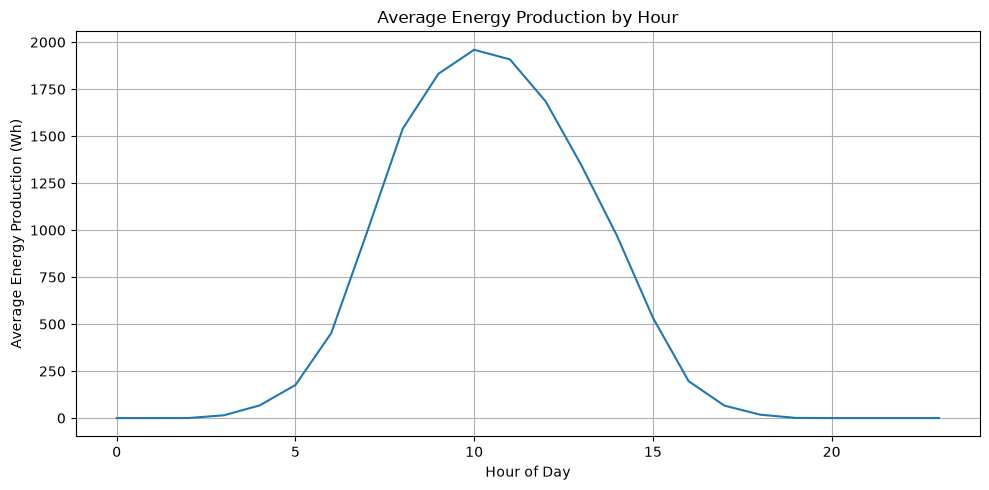

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

hourly_avg.plot()
plt.title("Average Energy Production by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Energy Production (Wh)")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/01_average_energy_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation:**

Energy production follows a bell-shaped daily pattern, with near-zero production during nighttime hours and peak production around 10:00.

**Interpretation:**

This pattern is characteristic of solar energy systems and indicates that energy generation is strongly influenced by daylight availability.

### Impact of Cloud Cover on Energy Production

In [12]:
cloud_energy = df.groupby("clouds_all")["Energy delta[Wh]"].mean()

cloud_energy.head()

clouds_all
0    913.801816
1    651.694640
2    790.908052
3    769.560219
4    738.896458
Name: Energy delta[Wh], dtype: float64

In [13]:
df["clouds_all"].describe()

count    196776.000000
mean         65.974387
std          36.628593
min           0.000000
25%          34.000000
50%          82.000000
75%         100.000000
max         100.000000
Name: clouds_all, dtype: float64

### Cloud Cover Effects During Sunlight Hours

In [14]:
sun_df = df[df["isSun"] == 1]

sun_df.shape

(102316, 17)

In [15]:
sun_cloud_energy = (
    sun_df.groupby("clouds_all")["Energy delta[Wh]"]
    .mean()
)

sun_cloud_energy.head()

clouds_all
0    1834.884922
1    1461.032411
2    1652.447560
3    1669.072559
4    1525.597750
Name: Energy delta[Wh], dtype: float64

### Average Energy Production by Cloud Cover During Sunlight Hours

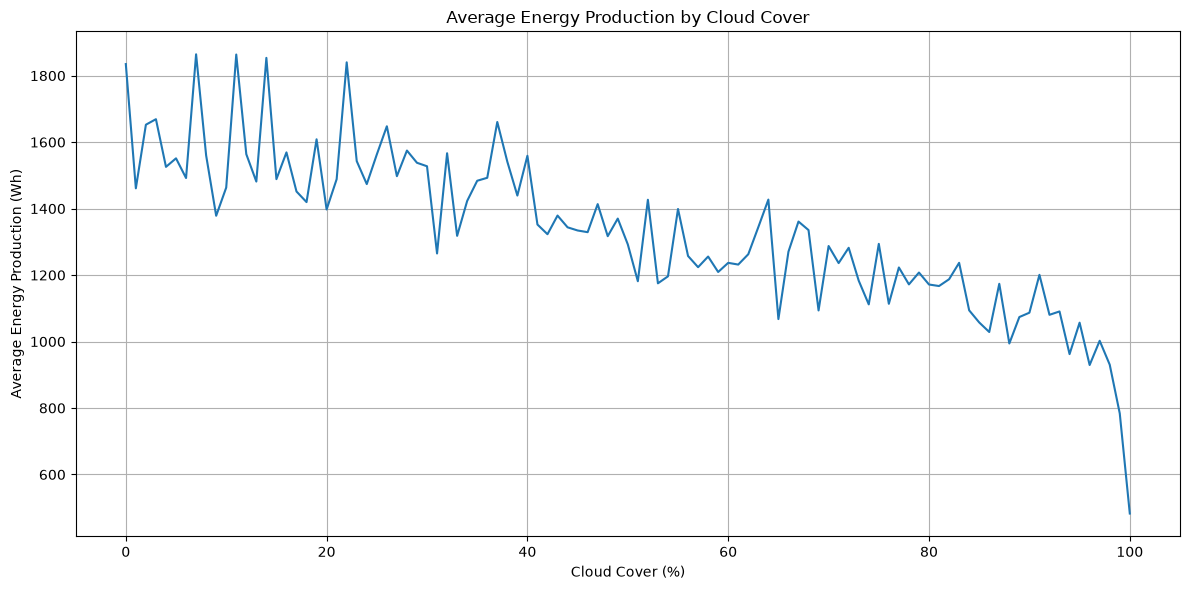

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

sun_cloud_energy.plot()

plt.title("Average Energy Production by Cloud Cover")
plt.xlabel("Cloud Cover (%)")
plt.ylabel("Average Energy Production (Wh)")

plt.grid(True)
plt.tight_layout()

plt.show()

**Observation:**

Average energy production generally decreases as cloud cover increases. Although the relationship contains fluctuations, the overall trend is negative, indicating that cloudier conditions are associated with lower renewable energy generation.

**Interpretation:**

Cloud cover reduces the amount of solar radiation reaching the system, which lowers energy production. This suggests that cloud cover is likely to be an important predictor in future machine learning models.

### Impact of Global Horizontal Irradiance (GHI) on Energy Production

In [17]:
df["GHI"].describe()

count    196776.000000
mean         32.596538
std          52.172018
min           0.000000
25%           0.000000
50%           1.600000
75%          46.800000
max         229.200000
Name: GHI, dtype: float64

### Relationship Between GHI and Energy Production

In [ ]:
ghi_energy = df.groupby("GHI")["Energy delta[Wh]"].mean()

ghi_energy.head()

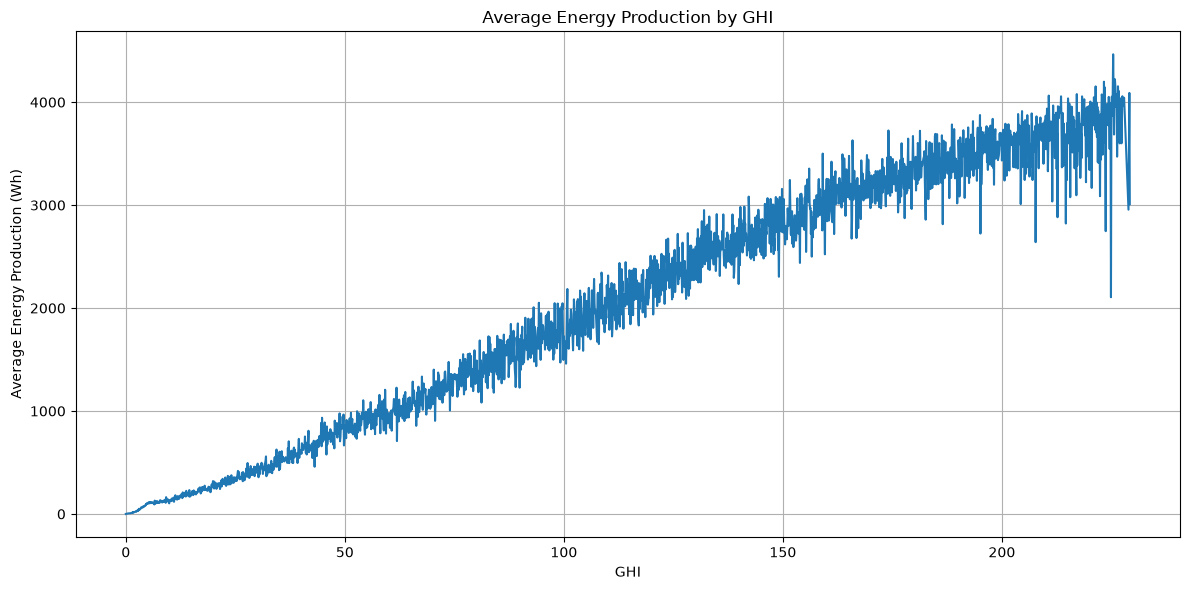

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

ghi_energy.plot()

plt.title("Average Energy Production by GHI")
plt.xlabel("GHI")
plt.ylabel("Average Energy Production (Wh)")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/03_ghi_vs_energy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation:**

Average energy production increases strongly as GHI increases. The relationship is much clearer than the relationship observed with cloud cover, indicating a strong positive association between solar irradiance and energy generation.

**Interpretation:**

GHI measures the amount of solar energy reaching the surface and is directly related to the physical process of solar power generation. The strong upward trend suggests that GHI will likely be one of the most important predictors in future machine learning models.

### Seasonal Patterns in Energy Production

In [23]:
monthly_avg = df.groupby("month")["Energy delta[Wh]"].mean()

monthly_avg

month
1     129.559145
2     369.194174
3     620.637209
4     851.112211
5     881.579693
6     926.396648
7     811.018425
8     798.917059
9     631.771875
10    397.342668
11    151.741611
12     91.229028
Name: Energy delta[Wh], dtype: float64

**Observation:**

Energy production exhibits a strong seasonal pattern. Average production increases steadily from January to June, peaks in June, and then gradually declines toward December.

**Interpretation:**

This behavior is consistent with solar energy systems, where longer daylight hours and higher solar irradiance during summer months lead to increased energy generation. Seasonal effects appear to be an important factor influencing renewable energy production.

### Average Energy Production by Month Visualization

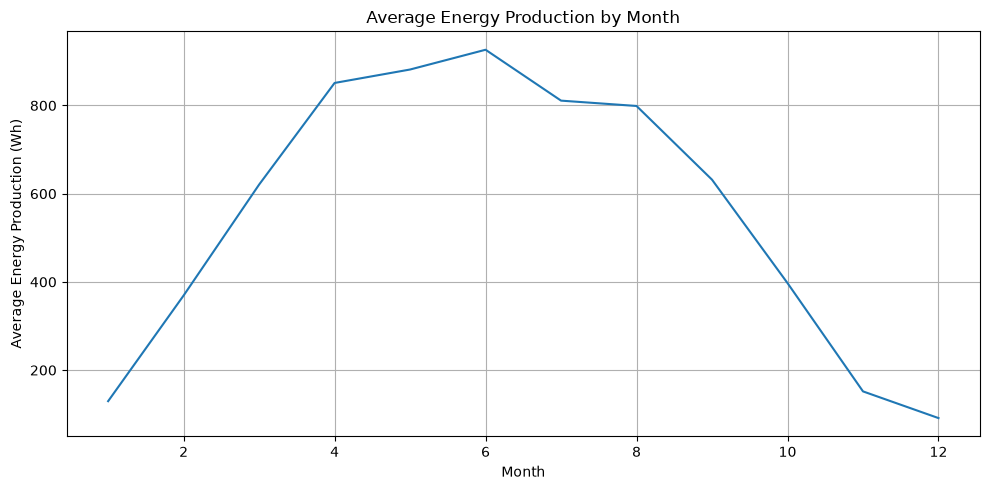

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

monthly_avg.plot()

plt.title("Average Energy Production by Month")
plt.xlabel("Month")
plt.ylabel("Average Energy Production (Wh)")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/04_average_energy_by_month.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


**Observation:**

Energy production exhibits a strong seasonal cycle. Average production increases from January to June, reaches its maximum in June, and then gradually decreases toward December.

**Interpretation:**

This pattern is consistent with solar energy systems, where longer daylight hours and higher solar irradiance during summer months increase energy generation. Seasonal effects appear to be one of the most influential factors affecting renewable energy production.

**Key Finding:**

Average energy production in June is approximately ten times higher than in December, highlighting the substantial impact of seasonality on renewable energy generation.

### Correlation Analysis

In [26]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix["Energy delta[Wh]"].sort_values(ascending=False)

Energy delta[Wh]          1.000000
GHI                       0.914619
isSun                     0.526952
sunlightTime              0.437296
SunlightTime/daylength    0.402523
temp                      0.378554
dayLength                 0.280695
pressure                  0.115219
wind_speed                0.029385
month                    -0.049307
snow_1h                  -0.050914
rain_1h                  -0.059881
hour                     -0.080877
weather_type             -0.170046
clouds_all               -0.190241
humidity                 -0.544407
Name: Energy delta[Wh], dtype: float64

**Observation:**

GHI exhibits the strongest positive correlation with energy production (0.915), indicating a very strong linear relationship between solar irradiance and energy generation.

Humidity shows the strongest negative correlation (-0.544), while cloud cover also demonstrates a negative relationship with energy production.

Temperature, sunlight availability, and sunlight duration all show meaningful positive relationships with the target variable.

**Interpretation:**

The correlation analysis confirms that solar irradiance is the most influential factor affecting energy production in this dataset. Weather conditions and sunlight-related variables appear to be important predictors and are likely to play a significant role in future machine learning models.

### Impact of Humidity on Energy Production

In [27]:
df["humidity"].describe()

count    196776.000000
mean         79.810566
std          15.604459
min          22.000000
25%          70.000000
50%          84.000000
75%          92.000000
max         100.000000
Name: humidity, dtype: float64

**Observation:**

Humidity levels are generally high throughout the dataset, with a median value of 84% and 75% of observations having humidity levels below 92%.

**Interpretation:**

The dataset is dominated by relatively humid conditions. Since humidity has already shown a strong negative correlation with energy production, it may play an important role in explaining renewable energy generation patterns either directly or through its relationship with cloud cover and solar irradiance.

### Relationship Between Humidity and Energy Production

In [28]:
humidity_energy = (
    df.groupby("humidity")["Energy delta[Wh]"]
    .mean()
)

humidity_energy.head()

humidity
22    2371.187500
23    2515.166667
24    2979.625000
25    1810.321429
26    2284.600000
Name: Energy delta[Wh], dtype: float64

In [29]:
humidity_energy.tail()

humidity
96     79.106192
97     59.815781
98     68.289718
99     64.433121
100    86.455773
Name: Energy delta[Wh], dtype: float64

**Observation:**

Average energy production is substantially higher under low-humidity conditions than under high-humidity conditions. Very dry conditions are associated with some of the highest observed average production values, while extremely humid conditions are associated with very low average production.

**Interpretation:**

This result supports the negative correlation observed earlier and suggests that humidity is strongly associated with renewable energy generation. High humidity may be linked to atmospheric conditions that reduce the amount of solar energy reaching the system.

### Average Energy Production by Humidity

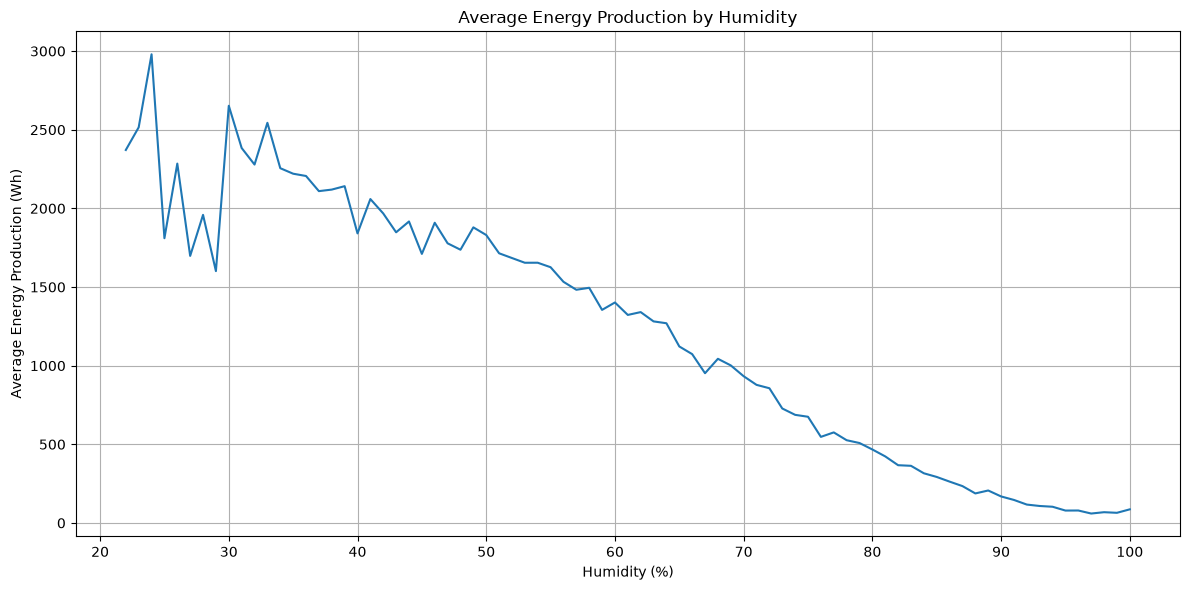

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

humidity_energy.plot()

plt.title("Average Energy Production by Humidity")
plt.xlabel("Humidity (%)")
plt.ylabel("Average Energy Production (Wh)")

plt.grid(True)
plt.tight_layout()

plt.savefig(
    "../outputs/figures/05_humidity_vs_energy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Observation:**

Average energy production decreases substantially as humidity increases. The relationship shows a clear negative trend, with low-humidity conditions associated with high energy production and high-humidity conditions associated with very low energy production.

**Interpretation:**

The humidity analysis supports the correlation results and suggests that humidity is an important factor associated with renewable energy generation. High humidity may be linked to atmospheric conditions that reduce solar irradiance and overall energy production.

**Key Finding:**

Humidity exhibits one of the strongest relationships with energy production in the dataset, second only to GHI.

### Correlation Heatmap

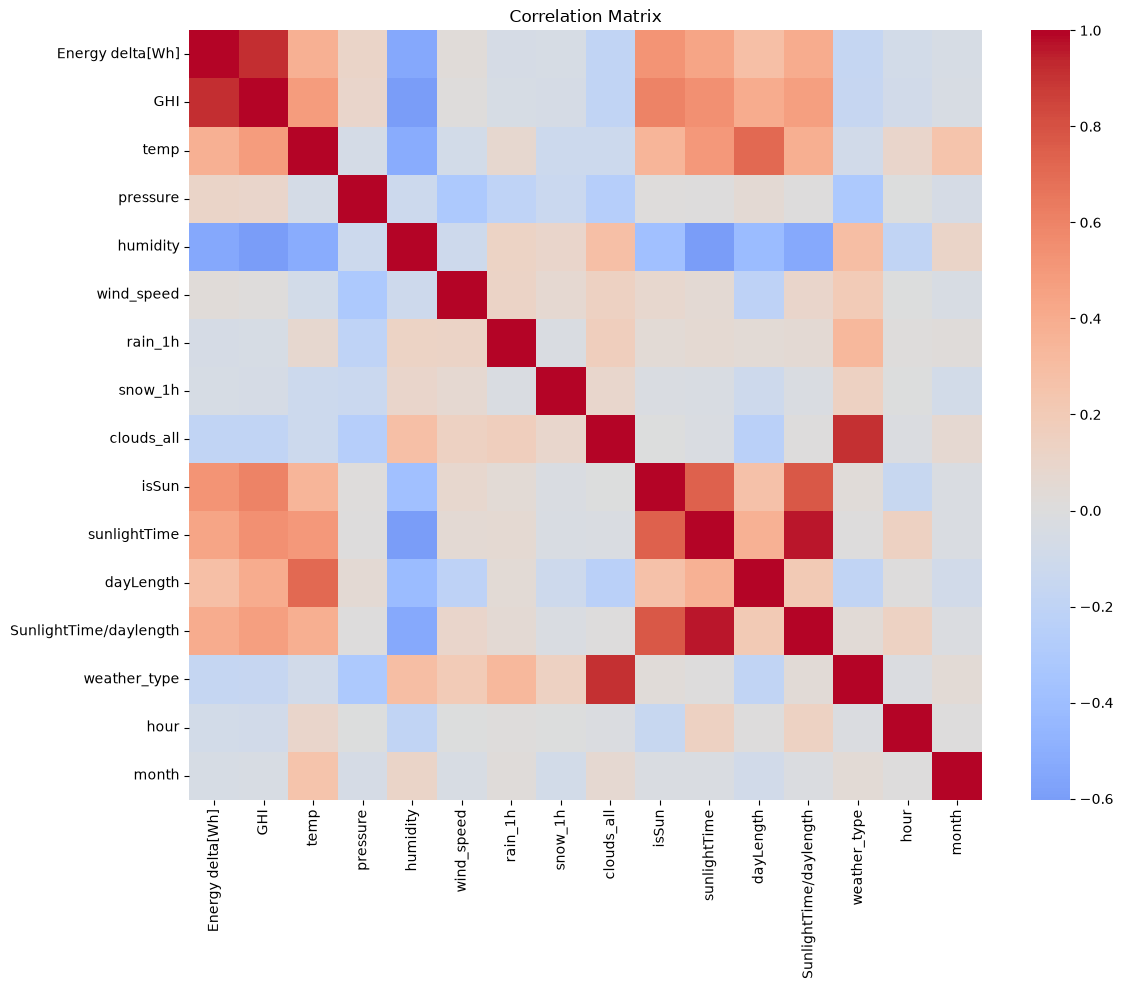

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()

plt.savefig(
    "../outputs/figures/06_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

**Observation:**

The correlation heatmap reveals strong relationships among several weather and sunlight-related variables. GHI shows the strongest positive association with energy production, while humidity exhibits a notable negative relationship.

**Interpretation:**

Several sunlight-related variables (isSun, sunlightTime, dayLength, and SunlightTime/daylength) are highly correlated with one another, suggesting they capture similar information. Humidity appears to be associated with lower solar irradiance and reduced energy production, indicating that weather conditions play an important role in renewable energy generation.

**Key Finding:**

The heatmap confirms that solar irradiance (GHI) is the dominant predictor of energy production and highlights important relationships between weather variables and sunlight availability.